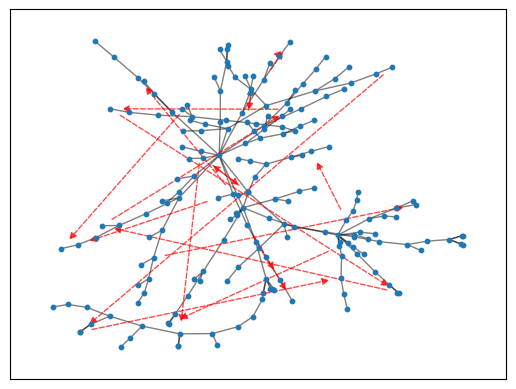

In [2]:
import json
import networkx as nx
import matplotlib.pyplot as plt
with open('vault/Tamagacha/Lineages.canvas', 'r') as f:
    canvas = json.load(f)
G = nx.DiGraph()
for node in canvas['nodes']:
    G.add_node(node['id'], label=node['file'].split('/')[-1].split('.')[-2])
for edge in canvas['edges']:
    G.add_edge(edge['fromNode'], edge['toNode'])


# 1. Build a spanning forest using the underlying undirected graph.
#    This is the structure we'll use for the layout.
UG = G.to_undirected()
T = nx.minimum_spanning_tree(UG)

# 2. Lay out the tree.
pos = nx.spring_layout(T, k=0.01)

# 3. Draw the tree edges normally.
nx.draw_networkx_nodes(G, pos, node_size=10)
nx.draw_networkx_edges(T, pos, alpha=0.5)

# 4. Draw edges that aren't in the tree differently.
tree_edges = set(T.edges())
extra_edges = [
    (u, v) for u, v in G.edges()
    if (u, v) not in tree_edges and (v, u) not in tree_edges
]

nx.draw_networkx_edges(
    G, pos,
    edgelist=extra_edges,
    edge_color="red",
    style="dashed",
    alpha=0.7,
    arrows=True,
)

# nx.draw_networkx_labels(G, pos)

plt.show()

In [23]:
import plotly.graph_objects as go
# Draw tree edges and non-tree edges separately.
tree_pairs = {frozenset(edge) for edge in T.edges()}
edge_groups = {
    "tree": {"x": [], "y": []},
    "extra": {"x": [], "y": []},
}

for u, v in G.edges():
    group = "tree" if frozenset((u, v)) in tree_pairs else "extra"
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_groups[group]["x"].extend([x0, x1, None])
    edge_groups[group]["y"].extend([y0, y1, None])

fig = go.Figure()

for group, color, dash in [
    ("tree", "gray", "solid"),
    ("extra", "red", "dash"),
]:
    fig.add_trace(go.Scatter(
        x=edge_groups[group]["x"],
        y=edge_groups[group]["y"],
        mode="lines",
        line=dict(color=color, width=1, dash=dash),
        hoverinfo="skip",
        showlegend=False,
    ))

# Add directional arrowheads.
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    is_extra = frozenset((u, v)) not in tree_pairs
    fig.add_annotation(
        x=x1, y=y1, ax=x0, ay=y0,
        xref="x", yref="y", axref="x", ayref="y",
        showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1,
        arrowcolor="red" if is_extra else "gray",
    )

nodes = list(G.nodes())
fig.add_trace(go.Scatter(
    x=[pos[n][0] for n in nodes],
    y=[pos[n][1] for n in nodes],
    mode="markers",
    text=[G.nodes[n].get("label", str(n)) for n in nodes],
    textposition="top center",
    marker=dict(size=9, color="royalblue"),
    hoverinfo="text",
    showlegend=False,
))

fig.update_layout(
    template="plotly_white",
    xaxis=dict(visible=False, scaleanchor="y"),
    yaxis=dict(visible=False),
    margin=dict(l=20, r=20, t=20, b=20),
)
fig.show()

In [3]:
from pathlib import Path
from PIL import Image

canvas_dir = Path("vault/Tamagacha")
assets_dir = Path("assets")
image_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif"}

for node in canvas.get("nodes", []):
    if node.get("type") != "file" or not node.get("file"):
        continue

    image_path = canvas_dir / node["file"]
    if image_path.suffix.lower() not in image_extensions or not image_path.is_file():
        continue

    output_dir = assets_dir / image_path.stem
    output_dir.mkdir(parents=True, exist_ok=True)

    with Image.open(image_path) as image:
        image = image.convert("RGB")
        width, height = image.size
        image = image.crop((20, 10, width - 20, height - 10))
        width, height = image.size

        for row in range(2):
            for col in range(4):
                left = col * width // 4
                right = (col + 1) * width // 4
                top = row * height // 2
                bottom = (row + 1) * height // 2

                tile = image.crop((left, top, right, bottom))
                tile = tile.resize(
                    (max(1, tile.width // 2), max(1, tile.height // 2)),
                    Image.Resampling.LANCZOS,
                )
                idx = row * 4 + col
                if idx == 4:
                    tile.save(output_dir / "5.jpg", "JPEG")
                elif idx == 5:
                    tile.save(output_dir / "4.jpg", "JPEG")
                else:
                    tile.save(output_dir / f"{idx}.jpg", "JPEG")